# B2 Multi-Arrangement

The **type $B_2$ arrangement** in $\mathbb{R}^3$ (homogenised) consists of the four hyperplanes
$$
  x = 0,\quad y = 0,\quad x - y = 0,\quad x + y = 0.
$$
These are the reflecting hyperplanes of the Coxeter group of type $B_2$.

We study **multi-arrangements** $(\mathcal{A}, \mathbf{m})$ obtained by assigning
multiplicities $\mathbf{m} = (m_1, m_2, m_3, m_4)$ to the hyperplanes.

In [2]:
import shutil, sys

_err = []
if shutil.which("sage") is None:
    _err.append("'sage' command not found on PATH.")
try:
    import sage.all
except ModuleNotFoundError:
    _err.append("SageMath is not available in this Python environment.")

if _err:
    from IPython.display import Markdown, display
    display(Markdown(
        "## ⚠ Wrong Kernel\n\n"
        + "\n".join(f"- {e}" for e in _err)
        + "\n\n**This notebook must be run with the SageMath kernel, not a plain Python kernel.**\n\n"
        "In JupyterLab: *Kernel → Change Kernel → SageMath*\n\n"
        "In VS Code: click the kernel name in the top-right corner and select *SageMath*."
    ))
    raise SystemExit("Switch to the SageMath kernel and re-run.")
else:
    print(f"OK: SageMath kernel (Python {sys.version.split()[0]})")

OK: SageMath kernel (Python 3.12.12)


In [ ]:
from IPython.display import Math, display
from matplotlib import pyplot as plt
import sage.misc.latex as sage_latex
import sys

sys.path.insert(0, './src')
from hyperplane_arrangements import *

# replace the default show function with one that works better in VSCode
import shutil, sys
try:
    original_show = show
except NameError:
    from IPython.display import Markdown, display
    display(Markdown(
        "## ⚠ Wrong Kernel\n\n"
        + "\n".join(f"- {e}" for e in _err)
        + "\n\n**This notebook must be run with the SageMath kernel, not a plain Python kernel.**\n\n"
        "In JupyterLab: *Kernel → Change Kernel → SageMath*\n\n"
        "In VS Code: click the kernel name in the top-right corner and select *SageMath*."
    ))
    raise SystemExit("Switch to the SageMath kernel and re-run.")
else:
    print(f"OK: SageMath kernel (Python {sys.version.split()[0]})")

def vscode_show(*args, **kwargs):
    for expr in args:
        try:
            if hasattr(expr, '_latex_'):
                display(Math(expr._latex_()))
            else:
                display(Math(sage_latex.latex(expr)))
        except Exception as e:
            print(f"LaTeX rendering failed: {e}")
            original_show(expr, **kwargs)
show = vscode_show
print(sage.version.banner)

## ⚠ Wrong Kernel



**This notebook must be run with the SageMath kernel, not a plain Python kernel.**

In JupyterLab: *Kernel → Change Kernel → SageMath*

In VS Code: click the kernel name in the top-right corner and select *SageMath*.

SystemExit: Switch to the SageMath kernel and re-run.

/opt/homebrew/Caskroom/miniforge/base/envs/sage/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Multi-arrangements with constant multiplicity

We assign the same multiplicity $m$ to every hyperplane of $\mathcal{A}(B_2)$:
$\mathbf{m} = (m, m, m, m)$.

It is always free.

In [11]:
# B2 arrangement: x, y, x-y, x+y  (homogenised with z)
mat_B2 = [[1, 0],   # x = 0
           [0, 1],   # y = 0
           [1, -1],  # x - y = 0
           [1, 1]]   # x + y = 0

for m in range(1, 5):
    Am = HyperPlaneArr(mat_B2, base_field=QQ, multiplicity=[m]*4)
    MG_m = Am.compute_multi_minimal_generators()
    degs_m = degseq(MG_m)
    is_free_m = len(degs_m) == Am.n
    print(f"m = {m}:  multiplicity = {Am.multiplicity},  "
          f"degree seq = {degs_m},  free? {is_free_m}")

m = 1:  multiplicity = [1, 1, 1, 1],  degree seq = [1, 3],  free? True
m = 2:  multiplicity = [2, 2, 2, 2],  degree seq = [4, 4],  free? True
m = 3:  multiplicity = [3, 3, 3, 3],  degree seq = [5, 7],  free? True
m = 4:  multiplicity = [4, 4, 4, 4],  degree seq = [8, 8],  free? True


## Multi-arrangements with varying multiplicities

Non-constant multiplicities.


In [14]:
from itertools import product as iprod

print(f"{'multiplicity':>20}  {'degree seq':>25}")
print("-" * 65)

for mult in iprod(range(1, 4), repeat=4):
    mult = list(mult)
    try:
        Am = HyperPlaneArr(mat_B2, base_field=QQ, multiplicity=mult)
        MG_m = Am.compute_multi_minimal_generators()
        degs_m = degseq(MG_m)
        is_free_m = len(degs_m) == Am.n
        print(f"{str(mult):>20}  {str(degs_m):>25}")
    except Exception as e:
        print(f"{str(mult):>20}  error: {e}")

        multiplicity                 degree seq
-----------------------------------------------------------------
        [1, 1, 1, 1]                     [1, 3]
        [1, 1, 1, 2]                     [2, 3]
        [1, 1, 1, 3]                     [3, 3]
        [1, 1, 2, 1]                     [2, 3]
        [1, 1, 2, 2]                     [3, 3]
        [1, 1, 2, 3]                     [3, 4]
        [1, 1, 3, 1]                     [3, 3]
        [1, 1, 3, 2]                     [3, 4]
        [1, 1, 3, 3]                     [3, 5]
        [1, 2, 1, 1]                     [2, 3]
        [1, 2, 1, 2]                     [3, 3]
        [1, 2, 1, 3]                     [3, 4]
        [1, 2, 2, 1]                     [3, 3]
        [1, 2, 2, 2]                     [3, 4]
        [1, 2, 2, 3]                     [4, 4]
        [1, 2, 3, 1]                     [3, 4]
        [1, 2, 3, 2]                     [4, 4]
        [1, 2, 3, 3]                     [4, 5]
        [1, 3, 1, 1]  

## Detailed look: a specific non-constant multiplicity


In [21]:
mult_example = [5, 6, 2, 2]
Am = HyperPlaneArr(mat_B2, base_field=QQ, multiplicity=mult_example)
MG_m = Am.compute_multi_minimal_generators()
degs_m = degseq(MG_m)
is_free_m = len(degs_m) == Am.n

print(f"Multiplicity: {mult_example}")
print(f"Degree sequence: {degs_m}")
print("Generators:")
for i, g in enumerate(MG_m):
    print(f"deg {max(c.degree() for c in g)}:")
    show(g)

Multiplicity: [5, 6, 2, 2]
Degree sequence: [7, 8]
Generators:
deg 7:


<IPython.core.display.Math object>

deg 8:


<IPython.core.display.Math object>

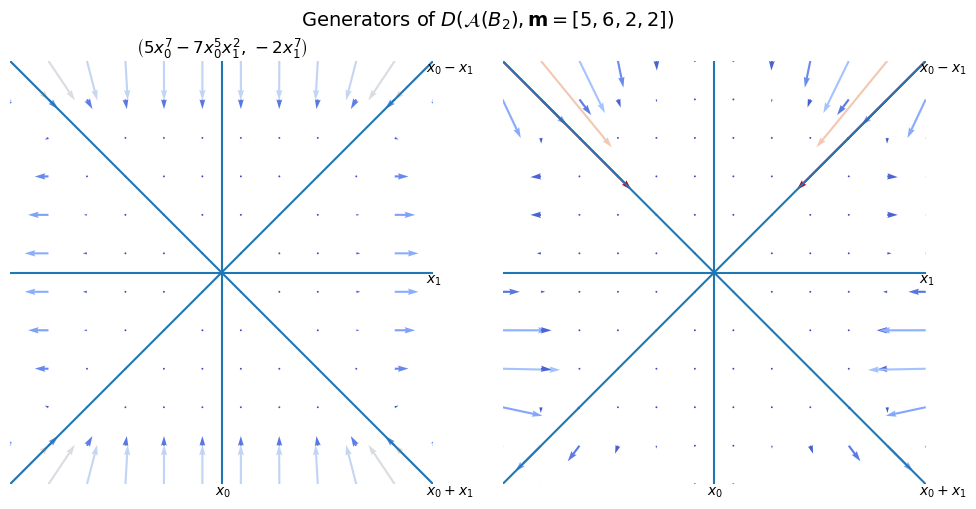

In [22]:
# Plot generators of the multi-arrangement
ncols = min(len(MG_m), 4)
nrows = (len(MG_m) + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)

for i, g in enumerate(MG_m):
    r, c = divmod(i, ncols)
    Am.plot(g, ax=axs[r][c], xlim=(-2, 2), ylim=(-2, 2), nx=12, ny=12, quiver=True)

# hide unused axes
for j in range(len(MG_m), nrows * ncols):
    r, c = divmod(j, ncols)
    axs[r][c].axis('off')

fig.suptitle(f'Generators of $D(\\mathcal{{A}}(B_2), \\mathbf{{m}}={mult_example})$', fontsize=14)
plt.tight_layout()